# **MLP for Image Classification**
The task is to create a Multilayer Perceptron (MLP) architecture as base for a ML model, the task is an image classification applied to the fashion_mnist dataset.
Such ML model will have several hyperparameters: number of dense layers, number of neuros per layer, activation function type along with weight initialization strategies, batch size, optimizer choice and number of epochs.

The objective e is to experiment with these hyperparameters to have the best corresponding MLP model among the possible hyperparameters configurations.

We first import the fundamental libraries for our task.

In [ ]:
# We want to import some libraries

import numpy as np # used to work on vectors

import tensorflow as tf # used for tensor manipulation

from sklearn.model_selection import train_test_split # It is used to split a dataset into traning and test set

from tensorflow import keras

import matplotlib.pyplot as plt #Used to plot images in python

### Import Dataset
The fashion_mnist is a dataset of Zalando's article images consisting of

*   60 000 images for the training set
*   10 000 images for the test set

Each image is a 28 x 28 grayscale image, associated with a label from 10 classes.
Classes includes t-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot.



In [ ]:
class_names = ['t-shirt', 'trouser','pullover','dress',
               'coat','sandal','shirt','sneaker','bag','ankle boot'];

len_class = len(class_names);

fashion_mnist = tf.keras.datasets.fashion_mnist;

(x_learn, y_learn),(x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step




*   x_learn and y_learn represent the
images and labeles used for the training and validation test
*   x_test and y_test represent the images and labels used for the testing phase



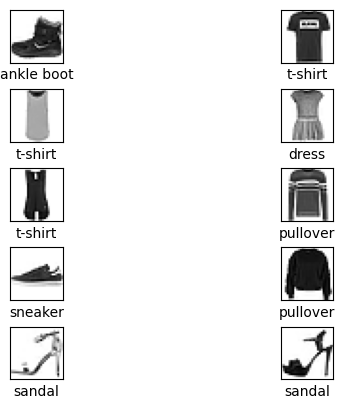

In [ ]:
for i in range(len_class):
 plt.subplot(5,2,i+1)
 plt.xticks([])
 plt.yticks([])
 plt.imshow(x_learn[i], cmap = plt.cm.binary)
 plt.xlabel(class_names[y_learn[i]])
 plt.subplots_adjust(hspace = 0.5)

### Preprocess the datas

###### Rescaling the datas
Rescale the learning and testing images RGB values in [0, 1];

In [ ]:
# Normalization of the images, learning and testing images RGB values in [0, 1]

# Set of images for testing and validation phase
x_learn = np.asarray(x_learn,dtype = np.float32)/255

# Set of images for testing phase
x_test = np.asarray(x_test,dtype = np.float32)/255

#### Datasplitting of the Learning datas
We split the learning data in testing and validation datas

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_learn, y_learn, train_size = 0.75, random_state = 12)

# train_size = 0.75 means thata 75% of datas x_learn and y_learn are considered as training data;
# random_state = 42 means that when splitting into training and validation test, the data is split in exactly the same way each time you run the code. the seed is 12

Checking of the shape:



* Training set
* Validation set






In [ ]:
print("The shape of the training set, images and labels is the following:")
print(x_train.shape)
print(y_train.shape)

print()

print("The shape of the validation test, images and labels is the following:")
print(x_val.shape)
print(y_val.shape)

The shape of the training set, images and labels is the following:
(45000, 28, 28)
(45000,)

The shape of the validation test, images and labels is the following:
(15000, 28, 28)
(15000,)


#### Standardization of the dataset
 We want apply the standardization of our training, validation and test set because  sometimes some samples exhibits higher magnitudes than other samples.
 Standardized samples are called z-scores.

 In our case the process of standardization consists of subtracting the mean of the mean values and dividing by the mean of the standard deviations, across the whole dataset and for each RGB channel.
 Doing so, the optimization space will be spatially homogenous and optmization process faster.

 At the bottom we compute the function that evaluates the mean and the standard deviation of a full dataset given in input.

In [ ]:
def standardize_dataset(X):
    image_means = []  # Empty vector
    image_stds =  []  # Empty vector

    for image in X:
        #TODO # Computing the image mean
        image_means.append(np.mean(image))

        #TODO # Computing the image standard deviation
        image_stds.append(np.std(image))

    #TODO dataset_mean = ... # Computing the dataset mean
    dataset_mean = np.sum(image_means) / len(X);

    #TODO dataset_std = ...  # Computing the dataset standard deviation
    dataset_std = np.sum(image_stds) / len(X);

    return [dataset_mean, dataset_std] # For every image we subtract to it the dataset mean and
                                       # we divide by the dataset standard deviation

Let's compute the mean and the standard deviation of the full training, validation and test set;
Later we will see the changes after the standardization.

In [ ]:
train_mean, train_dvt = standardize_dataset(x_train);
val_mean, val_dvt = standardize_dataset(x_val);
test_mean, test_dvt = standardize_dataset(x_test);

print("The mean and standard deviation of the Training set are the following:")
print(train_mean, end = " ")
print(train_dvt)

print()

print("The mean and standard deviation of the Validation set are the following:")
print(val_mean, end = " ")
print(val_dvt)

print()

print("The mean and standard deviation of the Test set are the following:")
print(test_mean, end = " ")
print(test_dvt)

The mean and standard deviation of the Training set are the following:
0.2856877 0.32004157

The mean and standard deviation of the Validation set are the following:
0.2870992 0.32087108

The mean and standard deviation of the Test set are the following:
0.28684932 0.31986475


Now we standardize the training, validation and test set.

In [ ]:
x_train_std = ( (x_train - train_mean) / train_dvt);

x_val_std = ( (x_val - val_mean) / val_dvt);

x_test_std = ( (x_test - test_mean) / test_dvt);

train_mean_std, train_dvt_std = standardize_dataset(x_train_std);
print("The mean and standard deviation of the Training set are the following:")
print(train_mean_std, end = " ")
print(train_dvt_std)

print()

val_mean_std, val_dvt_std = standardize_dataset(x_val_std);
print("The mean and standard deviation of the Validation set are the following:")
print(val_mean_std, end = " ")
print(val_dvt_std)

print()

test_mean_std, test_dvt_std = standardize_dataset(x_test_std)
print("The mean and standard deviation of the Test set are the following:")
print(test_mean_std, end = " ")
print(test_dvt_std)


The mean and standard deviation of the Training set are the following:
4.255507e-08 0.99999994

The mean and standard deviation of the Validation set are the following:
-4.83195e-08 1.0

The mean and standard deviation of the Test set are the following:
-1.1253357e-07 1.0


#### Label encoding
Up to know, classes are represented by a integer number. We want to convert them to a binary classification matrix.

In [ ]:
print("Class labels are encoded like that: ", y_train)

y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)
y_test = tf.keras.utils.to_categorical(y_test)

print()

print("After one-hot encoding, class labels are now encoded like this: ", y_train)

Class labels are encoded like that:  [3 5 4 ... 9 2 6]

After one-hot encoding, class labels are now encoded like this:  [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### History function
We define the "history function", which is able to plot accuracy and loss values for both testing set and validation set.

In [ ]:
def plot_history(history):

    # Plot training & validation accuracy values
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')

    plt.subplots_adjust(wspace = 0.7)

### **Building and training the MLP model, initial configuration**
Now the we have preprocessed the datas, our aim is to create the best MLP model based on the range of hypeparameters given:


*   **Number of dense layers:** 5, 10, 15;
*   **Number of neurons for each Dense Layer:** 32, 64, 128;
* **Activation function and corresponding weight initialization:** ReLu, Sigmoid, Tanh;
* **Batch size:** 32, 128, 256, 512;
* **Number of epochs:** 50, 100, 500;
* **Optimizer:** SGD, ADAM;

We will start with the initial configuration, we will vary only the number of dense layers keeping fixed the other hyperparamters in their initial values here presented.


In [ ]:
from keras.layers import Flatten, Dense, InputLayer

from keras.models import Sequential

from keras.optimizers import SGD

# Batch Size
batch_size = 32

# Number of epochs
epochs = 50

# Activation function
act_func = 'relu'


####**5 Dense Layers, 32 neurons, ReLu activation**


In [ ]:
model_5dl_32n = Sequential();

# Number of hidden layers and neuron per layers
n_hidden_layers = 5;
n_neurons = 32;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n.add(output)

model_5dl_32n.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_5dl_32n = model_5dl_32n.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1804 - loss: 2.1768 - val_accuracy: 0.4513 - val_loss: 1.4943
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5245 - loss: 1.3065 - val_accuracy: 0.6999 - val_loss: 0.8457
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6995 - loss: 0.8135 - val_accuracy: 0.7276 - val_loss: 0.7134
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7297 - loss: 0.7069 - val_accuracy: 0.7469 - val_loss: 0.6615
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7558 - loss: 0.6385 - val_accuracy: 0.7713 - val_loss: 0.6149
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7744 - loss: 0.5943 - val_accuracy: 0.7914 - val_loss: 0.5777
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7893 - loss: 0.5714 - val_accuracy: 0.8006 - val_loss: 0.5457
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8012 - loss: 0.5420 - 

#### **10 dense layers, 32 neurons, ReLu activation**

In [ ]:
model_10dl_32n = Sequential();

# Number of hidden layers and neuron per layers
n_hidden_layers = 10;
n_neurons = 32;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_10dl_32n.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_10dl_32n.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_10dl_32n.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_10dl_32n.add(output)

model_10dl_32n.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_10dl_32n.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_10dl_32n = model_10dl_32n.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,954 (136.54 KB)

 Trainable params: 34,954 (136.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1277 - loss: 2.2960 - val_accuracy: 0.2185 - val_loss: 2.2658
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2613 - loss: 2.2417 - val_accuracy: 0.2825 - val_loss: 2.0813
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2934 - loss: 1.9247 - val_accuracy: 0.4931 - val_loss: 1.3407
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5473 - loss: 1.2011 - val_accuracy: 0.6299 - val_loss: 0.9488
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6623 - loss: 0.8838 - val_accuracy: 0.6899 - val_loss: 0.7936
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7105 - loss: 0.7756 - val_accuracy: 0.6972 - val_loss: 0.7994
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7314 - loss: 0.7168 - val_accuracy: 0.7374 - val_loss: 0.7336
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7544 - loss: 0.6630 - 

#### **15 dense layers, 32 neurons, ReLu activation**

In [ ]:
model_15dl_32n = Sequential();

# Number of hidden layers and neuron per layers
n_hidden_layers = 15;
n_neurons = 32;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_15dl_32n.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_15dl_32n.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_15dl_32n.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_15dl_32n.add(output)

model_15dl_32n.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_15dl_32n.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_15dl_32n = model_15dl_32n.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,234 (157.16 KB)

 Trainable params: 40,234 (157.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0850 - loss: 2.3025 - val_accuracy: 0.0988 - val_loss: 2.3020
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0951 - loss: 2.3017 - val_accuracy: 0.0879 - val_loss: 2.3009
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1000 - loss: 2.3004 - val_accuracy: 0.1217 - val_loss: 2.2979
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1286 - loss: 2.2961 - val_accuracy: 0.1368 - val_loss: 2.2879
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1585 - loss: 2.2804 - val_accuracy: 0.1798 - val_loss: 2.2288
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1893 - loss: 2.1874 - val_accuracy: 0.2148 - val_loss: 2.0227
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2295 - loss: 1.9739 - val_accuracy: 0.2837 - val_loss: 1.8382
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3195 - loss: 1.7922 - 

### Evaluate the MLP model, initial configuration

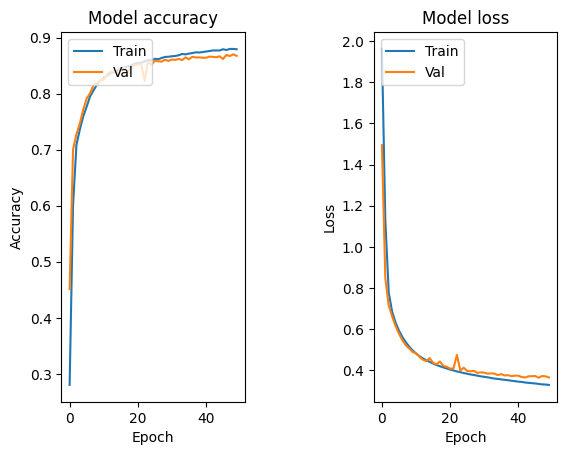

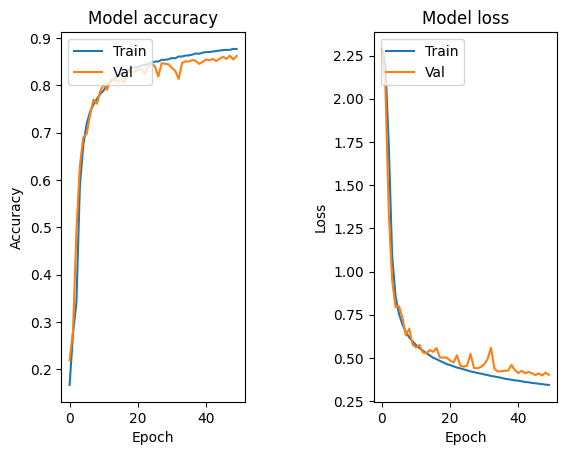

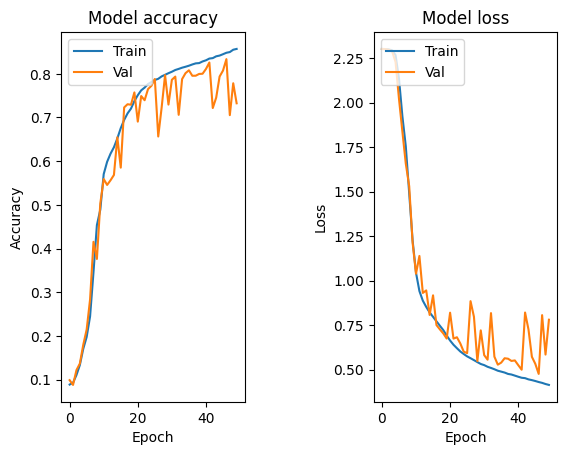

In [ ]:
plot_history(history_5dl_32n)
plt.show()

plot_history(history_10dl_32n)
plt.show()

plot_history(history_15dl_32n)

In [ ]:
# MODEL 1
train_loss, train_acc = model_5dl_32n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 2

train_loss, train_acc = model_10dl_32n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_10dl_32n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_10dl_32n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 2, 10 layers, 32 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 3
train_loss, train_acc = model_15dl_32n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_15dl_32n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_15dl_32n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 3, 15 layers, 32 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8826 - loss: 0.3275
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.3977
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8685 - loss: 0.3597
MODEL 1, 5 layers, 32 neurons

Final Training loss:
0.32712000608444214
Final Validation loss:
0.3647301495075226

Final Test loss:
0.4018252193927765
Final Test accuracy:
0.8532999753952026

Final Training accuracy:
0.882266640663147
Final Validation accuracy:
0.8673333525657654

Train: 0.882, Test: 0.853
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8815 - loss: 0.3378
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.4277
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8622 - loss: 0.3871
MODEL 2, 10 layers, 32 neurons

Final Training loss:
0.3378559648990631
Final Validation loss:
0.4013943076133728

Final Test loss:
0.44091030955314636
Final Test accuracy:
0.8511999845504761

Final Training accuracy:
0.8798444271087646
F

### **Building and training the MLP model, second configuration**

From the evaluation of the first MLP model configuration we can say that the best number of hidden layern is 5.
Now we modify the second hyperparameter, the number of neurons, our aim as before is to find the best possible configuration.

In [ ]:
# Batch size
batch_size = 32;

# Number of epochs
epochs = 50

####**5 Dense Layers, 32 neurons, ReLU activation**
Already done above

####**5 Dense Layers, 64 neurons, ReLU activation**

In [ ]:
model_5dl_64n = Sequential();

# Number of hidden layers
n_hidden_layers = 5;

# Number of neuron per layers
n_neurons = 64;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n.add(Dense(n_neurons,activation = 'relu'));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n.add(output)

model_5dl_64n.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_5dl_64n = model_5dl_64n.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2225 - loss: 2.1381 - val_accuracy: 0.6397 - val_loss: 1.1597
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6716 - loss: 1.0113 - val_accuracy: 0.7419 - val_loss: 0.7340
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7553 - loss: 0.6947 - val_accuracy: 0.7819 - val_loss: 0.6132
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7786 - loss: 0.6074 - val_accuracy: 0.7899 - val_loss: 0.5733
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7953 - loss: 0.5597 - val_accuracy: 0.8085 - val_loss: 0.5253
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8072 - loss: 0.5277 - val_accuracy: 0.8177 - val_loss: 0.5024
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8141 - loss: 0.5075 - val_accuracy: 0.8233 - val_loss: 0.4852
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8216 - loss: 0.4858 - 

####**5 Dense Layers, 128 neurons, ReLU activation**

In [ ]:
model_5dl_128n = Sequential();

# Number of hidden layers
n_hidden_layers = 5;

# Number of neuron per layers
n_neurons = 128;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n.add(Dense(n_neurons,activation = 'relu'));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n.add(output)

model_5dl_128n.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_5dl_128n = model_5dl_128n.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3706 - loss: 1.9142 - val_accuracy: 0.7172 - val_loss: 0.8498
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7283 - loss: 0.7761 - val_accuracy: 0.7737 - val_loss: 0.6281
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7828 - loss: 0.6105 - val_accuracy: 0.8001 - val_loss: 0.5504
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8017 - loss: 0.5469 - val_accuracy: 0.8068 - val_loss: 0.5289
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8170 - loss: 0.5083 - val_accuracy: 0.8303 - val_loss: 0.4790
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8267 - loss: 0.4828 - val_accuracy: 0.8306 - val_loss: 0.4694
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8318 - loss: 0.4643 - val_accuracy: 0.8395 - val_loss: 0.4476
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8388 - loss: 0.4538 -

#### **10 Dense Layers, 32 neurons, ReLU activation**
Already done above

#### **10 Dense Layers, 64 neurons, ReLU activation**

In [ ]:
model_10dl_64n = Sequential();

# Number of hidden layers
n_hidden_layers = 10;

# Number of hidden layers and neuron per layers
n_neurons = 64;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_10dl_64n.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_10dl_64n.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_10dl_64n.add(Dense(n_neurons,activation = 'relu'));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_10dl_64n.add(output)

model_10dl_64n.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_10dl_64n.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )


history_10dl_64n = model_10dl_64n.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,330 (345.04 KB)

 Trainable params: 88,330 (345.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1217 - loss: 2.2958 - val_accuracy: 0.1443 - val_loss: 2.2477
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1650 - loss: 2.1861 - val_accuracy: 0.3900 - val_loss: 1.9115
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4341 - loss: 1.8186 - val_accuracy: 0.5054 - val_loss: 1.5750
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5339 - loss: 1.5035 - val_accuracy: 0.5906 - val_loss: 1.2519
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6447 - loss: 1.1184 - val_accuracy: 0.7189 - val_loss: 0.7641
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7366 - loss: 0.7313 - val_accuracy: 0.7836 - val_loss: 0.6090
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7825 - loss: 0.6041 - val_accuracy: 0.8023 - val_loss: 0.5506
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8015 - loss: 0.5507 -

#### **10 Dense Layers, 128 neurons, ReLU activation**

In [ ]:
model_10dl_128n = Sequential();

# Number of hidden layers
n_hidden_layers = 10;

# Number of hidden layers and neuron per layers
n_neurons = 128;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_10dl_128n.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_10dl_128n.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_10dl_128n.add(Dense(n_neurons,activation = 'relu'));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_10dl_128n.add(output)

model_10dl_128n.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_10dl_128n.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )


history_10dl_128n = model_10dl_128n.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1315 - loss: 2.2853 - val_accuracy: 0.3273 - val_loss: 2.1572
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3486 - loss: 1.9495 - val_accuracy: 0.5946 - val_loss: 1.1212
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6166 - loss: 1.0056 - val_accuracy: 0.6856 - val_loss: 0.7945
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7115 - loss: 0.7658 - val_accuracy: 0.6810 - val_loss: 0.7269
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7560 - loss: 0.6432 - val_accuracy: 0.7296 - val_loss: 0.6644
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7799 - loss: 0.5832 - val_accuracy: 0.7768 - val_loss: 0.5897
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7974 - loss: 0.5472 - val_accuracy: 0.8017 - val_loss: 0.5480
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8122 - loss: 0.5092

### Evaluate the MLP model, second configuration with 5 Dense layers

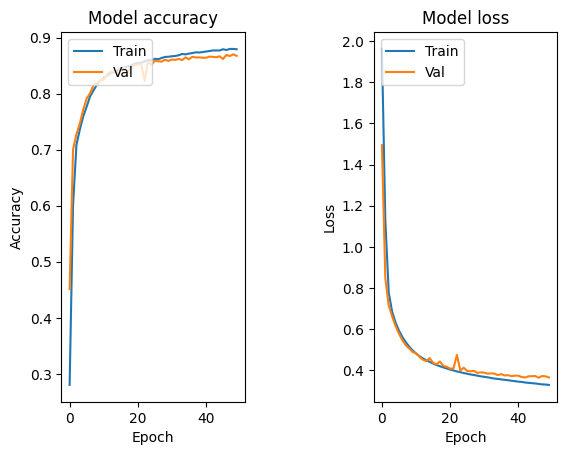

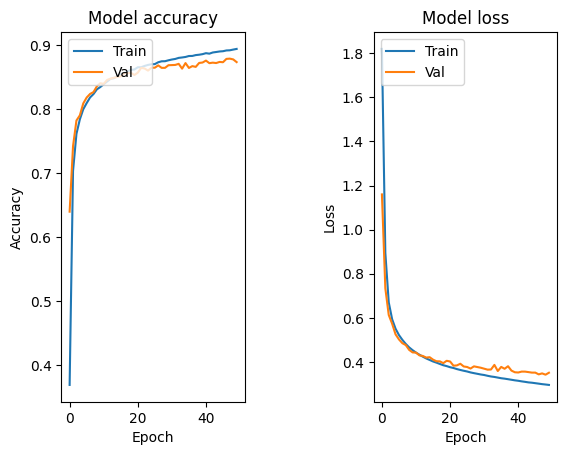

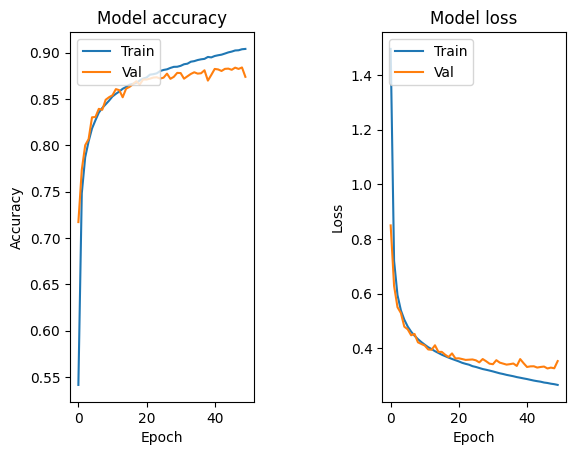

In [ ]:
plot_history(history_5dl_32n)
plt.show()

plot_history(history_5dl_64n)
plt.show()

plot_history(history_5dl_128n)

In [ ]:
# MODEL 1
train_loss, train_acc = model_5dl_32n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 2

train_loss, train_acc = model_5dl_64n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 2, 5 layers, 64 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 3
train_loss, train_acc = model_5dl_128n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 3, 5 layers, 128 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8826 - loss: 0.3275
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.3977
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8685 - loss: 0.3597
MODEL 1, 5 layers, 32 neurons

Final Training loss:
0.32712000608444214
Final Validation loss:
0.3647301495075226

Final Test loss:
0.4018252193927765
Final Test accuracy:
0.8532999753952026

Final Training accuracy:
0.882266640663147
Final Validation accuracy:
0.8673333525657654

Train: 0.882, Test: 0.853
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8909 - loss: 0.3008
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8640 - loss: 0.3866
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8732 - loss: 0.3460
MODEL 2, 5 layers, 64 neurons

Final Training loss:
0.3001987934112549
Final Validation loss:
0.35142213106155396

Final Test loss:
0.38769611716270447
Final Test accuracy:
0.8611999750137329

Final Training accuracy:
0.8907555341720581
F

### Evaluate the MLP model, second configuration with 10 Dense layers

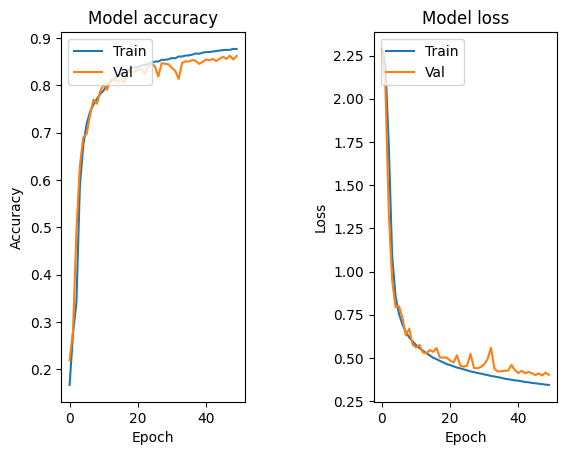

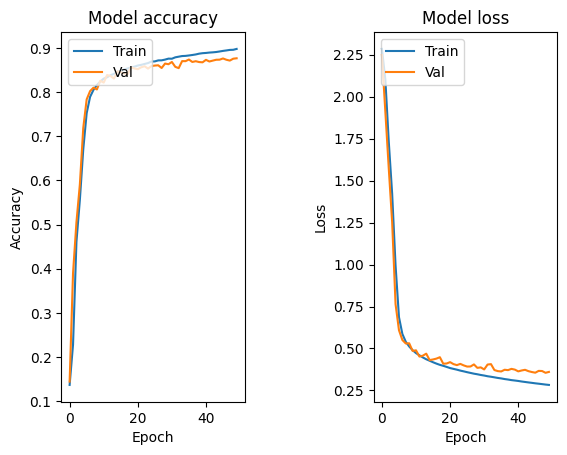

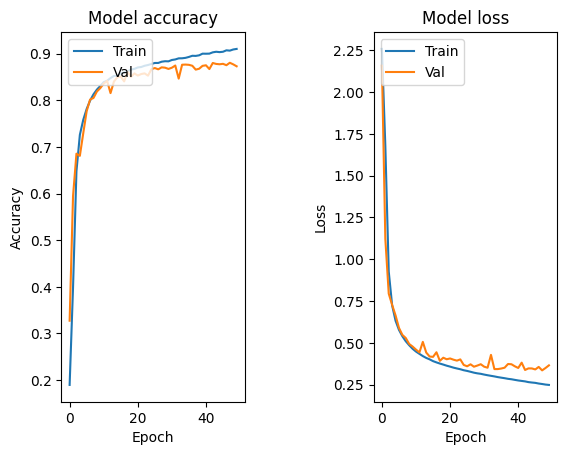

In [ ]:
plot_history(history_10dl_32n)
plt.show()

plot_history(history_10dl_64n)
plt.show()

plot_history(history_10dl_128n)

In [ ]:
# MODEL 1
train_loss, train_acc = model_10dl_32n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_10dl_32n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_10dl_32n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 10 layers, 32 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 2

train_loss, train_acc = model_10dl_64n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_10dl_64n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_10dl_64n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 2, 10 layers, 64 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 3
train_loss, train_acc = model_10dl_128n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_10dl_128n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_10dl_128n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 3, 10 layers, 128 neurons")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8815 - loss: 0.3378
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.4277
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8622 - loss: 0.3871
MODEL 1, 10 layers, 32 neurons

Final Training loss:
0.3378559648990631
Final Validation loss:
0.4013943076133728

Final Test loss:
0.44091030955314636
Final Test accuracy:
0.8511999845504761

Final Training accuracy:
0.8798444271087646
Final Validation accuracy:
0.8618000149726868

Train: 0.880, Test: 0.851
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8982 - loss: 0.2820
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.3879
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8778 - loss: 0.3498
MODEL 2, 10 layers, 64 neurons

Final Training loss:
0.28123709559440613
Final Validation loss:
0.36048445105552673

Final Test loss:
0.39107590913772583
Final Test accuracy:
0.8640999794006348

Final Training accuracy:
0.89773333072662

### **Comments**
Until now, considering the hyperparameters that we have tested, we found that the best MLP model is the one with 5 hidden layers and 32 neurons for layer, considering that we are using less parameters than the one with 64 and 128 neurons even if the validation accuracy is less than the other two.
However we decide also to test the one that has 5 Dense hidden layers with 64 and 128 neurons for layer.

what we want to do is to consider a different activation function for our models, until now we used ReLu as activation function now we test also Sigmoid and Tanh.


### **Building and training the MLP model, third configuration**
In this case we decide to test the three different activation functions on the models that have 5 Dense hidden Layers and 32, 64 and 128 neurons.

In the case of the Sigmoid activation function we will prove that has bad effects on the model 5 Dense hidden Layers and 32 neurons thus we will not prove it on the models with 64 and 128 neurons

In [ ]:
# Number of hidden layers
n_hidden_layers = 5;

# Batch size
batch_size = 32;

# Number of epochs
epochs = 50

#### **5 hidden layer, 32 neuron for layer, ReLu activation function**

Already treated above

#### **5 hidden layers, 32 neurons for layer, Sigmoid activation function**

In [ ]:
model_5dl_32n_sigmoid = Sequential();

# Number of neurons for each hidden layer
n_neurons = 32

# Activation function
act_func = 'sigmoid'

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_sigmoid.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_sigmoid.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_sigmoid.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_sigmoid.add(output)

model_5dl_32n_sigmoid.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_sigmoid.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_5dl_32n_sigmoid = model_5dl_32n_sigmoid.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_70 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_72 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1006 - loss: 2.4117 - val_accuracy: 0.1007 - val_loss: 2.3145
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1006 - loss: 2.3093 - val_accuracy: 0.1007 - val_loss: 2.3035
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1006 - loss: 2.3034 - val_accuracy: 0.0867 - val_loss: 2.3027
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0994 - loss: 2.3026 - val_accuracy: 0.1203 - val_loss: 2.3026
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1060 - loss: 2.3025 - val_accuracy: 0.0967 - val_loss: 2.3026
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1032 - loss: 2.3024 - val_accuracy: 0.1255 - val_loss: 2.3025
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1081 - loss: 2.3024 - val_accuracy: 0.1004 - val_loss: 2.3025
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1085 - loss: 2.3025 - 

#### **5 hidden layer, 32 neurons for layer, Tanh activation function**

In [ ]:
model_5dl_32n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 32

# Activation function
act_func = 'tanh'

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_5dl_32n_tanh = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_73 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_74 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_75 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_76 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_77 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_78 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4028 - loss: 1.8709 - val_accuracy: 0.6553 - val_loss: 1.2704
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6730 - loss: 1.1899 - val_accuracy: 0.7239 - val_loss: 0.9833
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7275 - loss: 0.9461 - val_accuracy: 0.7499 - val_loss: 0.8363
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7509 - loss: 0.8182 - val_accuracy: 0.7615 - val_loss: 0.7470
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7654 - loss: 0.7361 - val_accuracy: 0.7752 - val_loss: 0.6870
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7774 - loss: 0.6767 - val_accuracy: 0.7837 - val_loss: 0.6446
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7900 - loss: 0.6354 - val_accuracy: 0.7961 - val_loss: 0.6097
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8002 - loss: 0.6001 - 

#### **5 Dense Layer, 64 neurons, ReLU activation**
Already done above

#### **5 Dense Layer, 64 neurons, Tanh activation**

In [ ]:
model_5dl_64n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 64

# Activation function
act_func = 'tanh'

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_5dl_64n_tanh = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_79 (Dense)                     │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_80 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_81 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_82 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_83 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_84 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4375 - loss: 1.7607 - val_accuracy: 0.7219 - val_loss: 1.0248
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7376 - loss: 0.9405 - val_accuracy: 0.7612 - val_loss: 0.7759
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7651 - loss: 0.7461 - val_accuracy: 0.7851 - val_loss: 0.6663
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7846 - loss: 0.6547 - val_accuracy: 0.8011 - val_loss: 0.6008
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8061 - loss: 0.5902 - val_accuracy: 0.8127 - val_loss: 0.5573
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8173 - loss: 0.5504 - val_accuracy: 0.8221 - val_loss: 0.5267
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8239 - loss: 0.5208 - val_accuracy: 0.8292 - val_loss: 0.5041
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8290 - loss: 0.5004 - 

#### **5 Dense Layer, 128 neurons, ReLU activation**
Already done above

#### **5 Dense Layer, 128 neurons, Tanh activation**

In [ ]:
model_5dl_128n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 128

# Activation function
act_func = 'tanh'

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_5dl_128n_tanh = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_85 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_86 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_87 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_88 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_89 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_90 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5210 - loss: 1.5296 - val_accuracy: 0.7518 - val_loss: 0.8014
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7606 - loss: 0.7553 - val_accuracy: 0.7893 - val_loss: 0.6353
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7907 - loss: 0.6223 - val_accuracy: 0.8106 - val_loss: 0.5610
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8075 - loss: 0.5528 - val_accuracy: 0.8216 - val_loss: 0.5181
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8193 - loss: 0.5144 - val_accuracy: 0.8289 - val_loss: 0.4880
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8268 - loss: 0.4926 - val_accuracy: 0.8343 - val_loss: 0.4668
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8344 - loss: 0.4697 - val_accuracy: 0.8403 - val_loss: 0.4501
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8386 - loss: 0.4544 

### Evaluate the MLP model, third configuration (5 Dense Layers and 32 neurons)

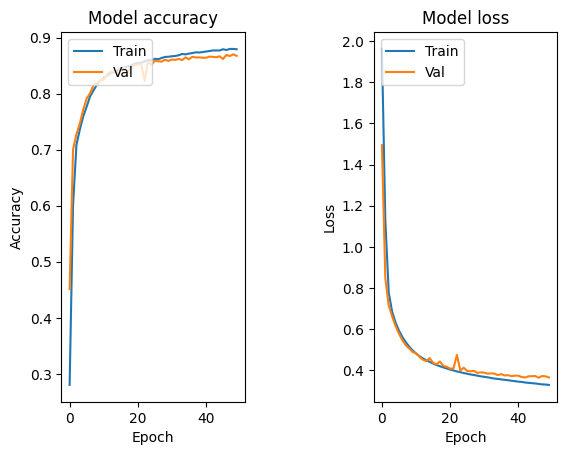

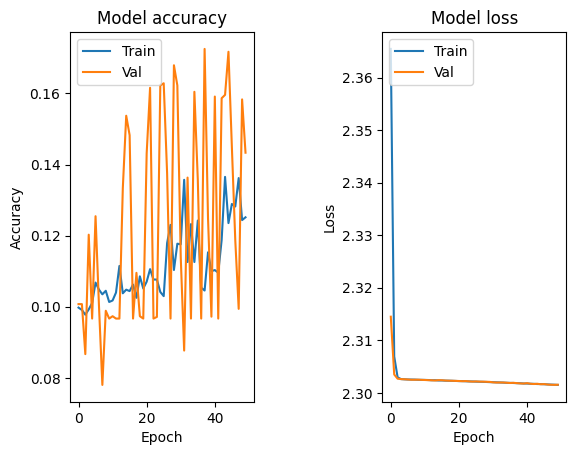

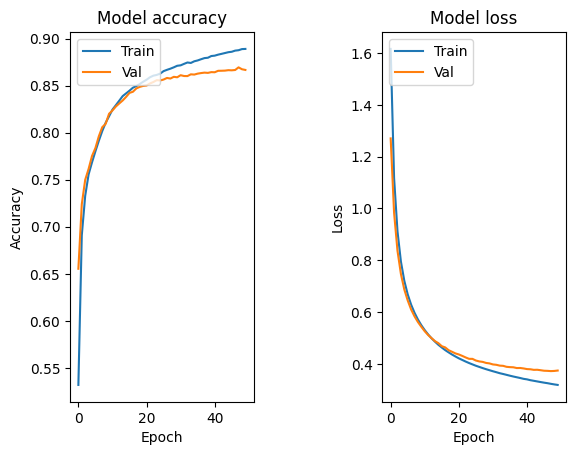

In [ ]:
plot_history(history_5dl_32n)
plt.show()

plot_history(history_5dl_32n_sigmoid)
plt.show()

plot_history(history_5dl_32n_tanh)

In [ ]:
# MODEL 1
train_loss, train_acc = model_5dl_32n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, ReLu activation function")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 2

train_loss, train_acc = model_5dl_32n_sigmoid.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_sigmoid.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_sigmoid.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 2, 5 layers, 32 neurons, Sigmoid activation function")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 3
train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 3, 5 layers, 32 neurons, Tanh activation function")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8826 - loss: 0.3275
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.3977
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8685 - loss: 0.3597
MODEL 1, 5 layers, 32 neurons, ReLu activation function

Final Training loss:
0.32712000608444214
Final Validation loss:
0.3647301495075226

Final Test loss:
0.4018252193927765
Final Test accuracy:
0.8532999753952026

Final Training accuracy:
0.882266640663147
Final Validation accuracy:
0.8673333525657654

Train: 0.882, Test: 0.853
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1476 - loss: 2.3014
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1424 - loss: 2.3015
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1473 - loss: 2.3015
MODEL 2, 5 layers, 32 neurons, Sigmoid activation function

Final Training loss:
2.3013854026794434
Final Validation loss:
2.3015382289886475

Final Test loss:
2.3014280796051025
Final Test accuracy:
0.1448000073

### Evaluate the MLP model, third configuration (5 Dense Layers and 64 neurons)

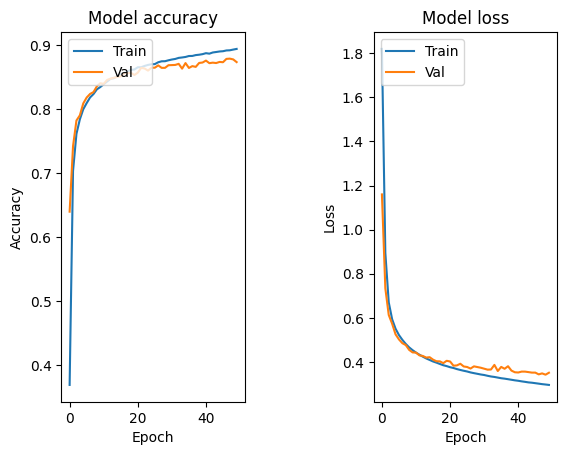

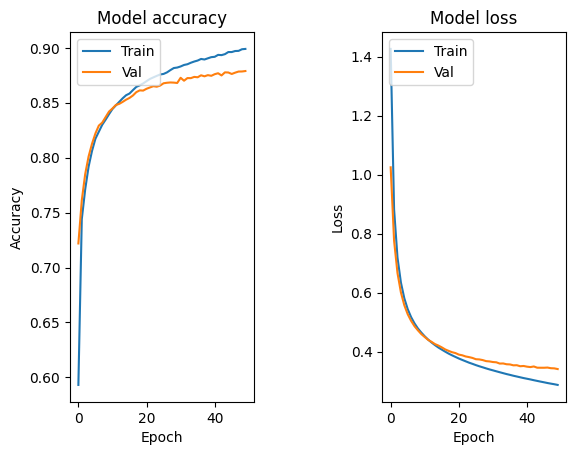

In [ ]:
plot_history(history_5dl_64n)
plt.show()

plot_history(history_5dl_64n_tanh)
plt.show()

In [ ]:
# MODEL 1
train_loss, train_acc = model_5dl_64n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, ReLu activation function")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 2
train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 3, 5 layers, 64 neurons, Tanh activation function")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8909 - loss: 0.3008
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - loss: 0.3866
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8732 - loss: 0.3460
MODEL 1, 5 layers, 64 neurons, ReLu activation function

Final Training loss:
0.3001987934112549
Final Validation loss:
0.35142213106155396

Final Test loss:
0.38769611716270447
Final Test accuracy:
0.8611999750137329

Final Training accuracy:
0.8907555341720581
Final Validation accuracy:
0.8730000257492065

Train: 0.891, Test: 0.861
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9005 - loss: 0.2850
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8714 - loss: 0.3807
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8815 - loss: 0.3303
MODEL 3, 5 layers, 64 neurons, Tanh activation function

Final Training loss:
0.2833189070224762
Final Validation loss:
0.3407558500766754

Final Test loss:
0.3816899061203003
Final Test accuracy:
0.86549997329

### Evaluate the MLP model, third configuration (5 Dense Layers and 128 neurons)

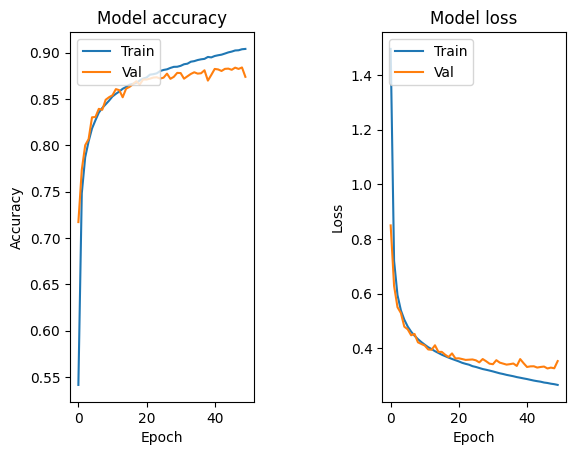

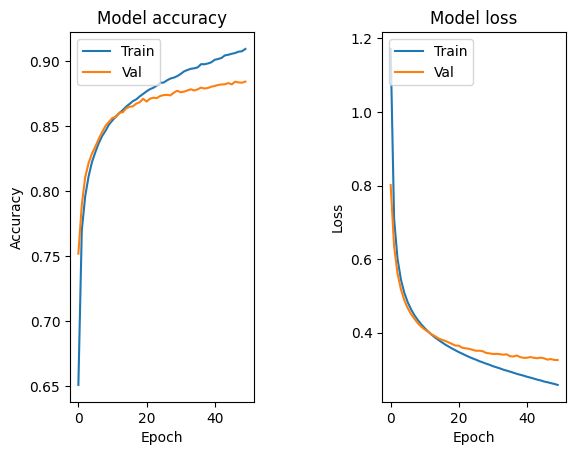

In [ ]:
plot_history(history_5dl_128n)
plt.show()

plot_history(history_5dl_128n_tanh)
plt.show()

In [ ]:
# MODEL 1
train_loss, train_acc = model_5dl_128n.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, ReLu activation function")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

#MODEL 2
train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 3, 5 layers, 128 neurons, Tanh activation function")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8928 - loss: 0.2910
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8602 - loss: 0.3968
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8751 - loss: 0.3476
MODEL 1, 5 layers, 128 neurons, ReLu activation function

Final Training loss:
0.28976336121559143
Final Validation loss:
0.3531225025653839

Final Test loss:
0.3970845341682434
Final Test accuracy:
0.8586999773979187

Final Training accuracy:
0.8937777876853943
Final Validation accuracy:
0.8740000128746033

Train: 0.894, Test: 0.859
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9114 - loss: 0.2543
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8737 - loss: 0.3626
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8861 - loss: 0.3175
MODEL 3, 5 layers, 128 neurons, Tanh activation function

Final Training loss:
0.25204211473464966
Final Validation loss:
0.3256101608276367

Final Test loss:
0.36238521337509155
Final Test accuracy:
0.87059998

### **Building, training and evaluation MLP model, fourth configuration**
Now we test our best models with different batch size, as models choose 5 dense layers, 32, 64, 128 neurons and tanh activation for all of them.

In [ ]:
# Number of hidden layers
n_hidden_layers = 5;

# Batch size
batch_size = [32, 128, 256, 512]

# Epochs
epochs = 50

#### **5 hidden layers, 32 neurons, Tanh activation fucntion**

In [ ]:
# Activation function
act_func = 'tanh'

#### 32 Batch Size

In [ ]:
train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 32 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8888 - loss: 0.3181
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.3995
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8696 - loss: 0.3662
MODEL 1, 5 layers, 32 neurons, Tanh activation function, 32 batch size

Final Training loss:
0.3166641294956207
Final Validation loss:
0.3739486634731293

Final Test loss:
0.40376704931259155
Final Test accuracy:
0.855400025844574

Final Training accuracy:
0.8889111280441284
Final Validation accuracy:
0.8666666746139526

Train: 0.889, Test: 0.855


#### 128 batch size


In [ ]:
model_5dl_32n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 32

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_128batchsize = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size[1], epochs = epochs, validation_data = (x_val_std, y_val));
print()


train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 128 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_91 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_92 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_93 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_94 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_95 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_96 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1531 - loss: 2.2850 - val_accuracy: 0.3719 - val_loss: 1.9049
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4126 - loss: 1.8418 - val_accuracy: 0.5106 - val_loss: 1.6767
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5261 - loss: 1.6377 - val_accuracy: 0.5749 - val_loss: 1.5144
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5872 - loss: 1.4835 - val_accuracy: 0.6250 - val_loss: 1.3849
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6294 - loss: 1.3624 - val_accuracy: 0.6618 - val_loss: 1.2757
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6648 - loss: 1.2586 - val_accuracy: 0.6859 - val_loss: 1.1828
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6846 - loss: 1.1708 - val_accuracy: 0.7016 - val_loss: 1.1035
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7067 - loss: 1.0907 - val_accuracy: 0.

#### 256 batch size

In [ ]:
model_5dl_32n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 32

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_256batchsize = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size[2], epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 256 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_97 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_98 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_99 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_100 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_101 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_102 (Dense)                    │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1247 - loss: 2.2860 - val_accuracy: 0.2679 - val_loss: 2.0381
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3147 - loss: 1.9833 - val_accuracy: 0.4225 - val_loss: 1.8484
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4543 - loss: 1.8086 - val_accuracy: 0.5082 - val_loss: 1.7141
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5264 - loss: 1.6811 - val_accuracy: 0.5511 - val_loss: 1.6041
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5635 - loss: 1.5780 - val_accuracy: 0.5843 - val_loss: 1.5102
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5988 - loss: 1.4841 - val_accuracy: 0.6217 - val_loss: 1.4281
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6268 - loss: 1.4084 - val_accuracy: 0.6466 - val_loss: 1.3554
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6458 - loss: 1.3408 - val_accuracy: 0

#### 512 batch size

In [ ]:
model_5dl_32n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 32

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_512batchsize = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size[3], epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 512 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_103 (Dense)                    │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_104 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_105 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_106 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_107 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_108 (Dense)                    │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1320 - loss: 2.3439 - val_accuracy: 0.2671 - val_loss: 2.1047
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2957 - loss: 2.0498 - val_accuracy: 0.3797 - val_loss: 1.9069
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3903 - loss: 1.8773 - val_accuracy: 0.4510 - val_loss: 1.7861
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4560 - loss: 1.7671 - val_accuracy: 0.5001 - val_loss: 1.7001
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5033 - loss: 1.6837 - val_accuracy: 0.5337 - val_loss: 1.6316
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5315 - loss: 1.6215 - val_accuracy: 0.5580 - val_loss: 1.5737
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5568 - loss: 1.5623 - val_accuracy: 0.5795 - val_loss: 1.5231
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5772 - loss: 1.5198 - val_accuracy: 0.5950 - val_lo

#### Plot evaluation

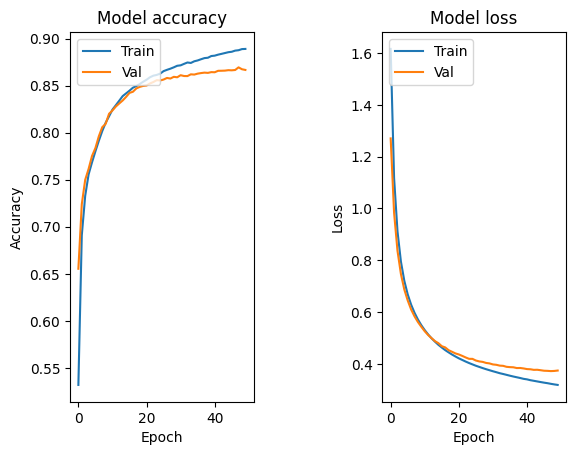

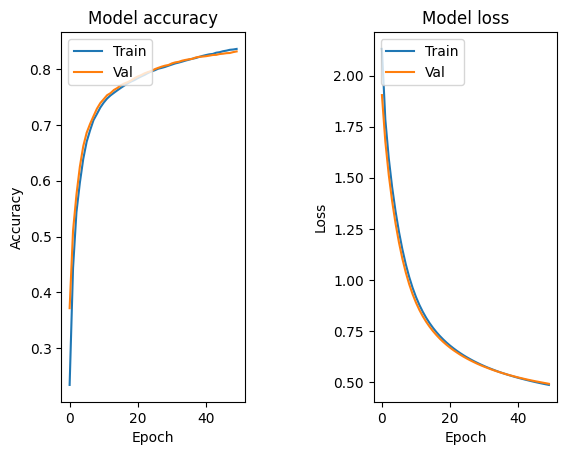

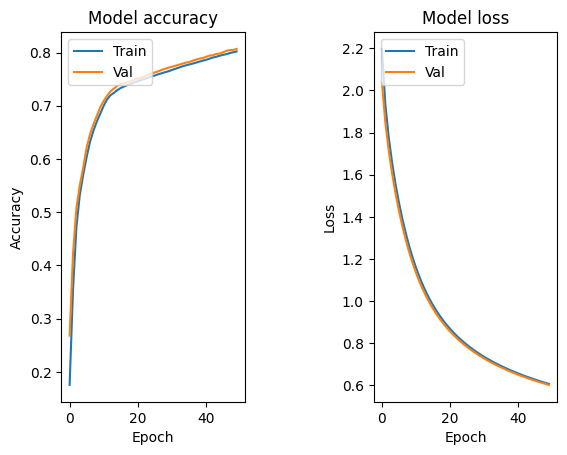

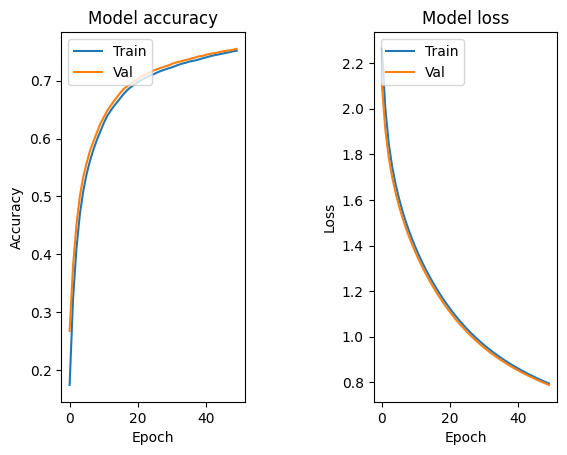

In [ ]:
plot_history(history_5dl_32n_tanh)
plt.show()

plot_history(history_128batchsize)
plt.show()

plot_history(history_256batchsize)
plt.show()

plot_history(history_512batchsize)

#### **5 hidden layers, 64 neurons, Tanh activation function**

In [ ]:
# Activation function
act_func = 'tanh'

#### 32 Batch Size

In [ ]:
train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 32 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9005 - loss: 0.2850
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8714 - loss: 0.3807
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8815 - loss: 0.3303
MODEL 1, 5 layers, 64 neurons, Tanh activation function, 32 batch size

Final Training loss:
0.2833189070224762
Final Validation loss:
0.3407558500766754

Final Test loss:
0.3816899061203003
Final Test accuracy:
0.8654999732971191

Final Training accuracy:
0.9013555645942688
Final Validation accuracy:
0.8788666725158691

Train: 0.901, Test: 0.865


#### 128 Batch Size

In [ ]:
model_5dl_64n_tanh = Sequential();

# Number of hidden layers
n_hidden_layers = 5;

# Number of neuron per layers
n_neurons = 64;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_128batchsize = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size[1], epochs = epochs, validation_data = (x_val_std, y_val));

train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 128 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_109 (Dense)                    │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_110 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_111 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_112 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_113 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_114 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3163 - loss: 2.0358 - val_accuracy: 0.5646 - val_loss: 1.5885
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5833 - loss: 1.5095 - val_accuracy: 0.6518 - val_loss: 1.3029
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6572 - loss: 1.2589 - val_accuracy: 0.6927 - val_loss: 1.1217
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6936 - loss: 1.0930 - val_accuracy: 0.7170 - val_loss: 0.9967
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7165 - loss: 0.9757 - val_accuracy: 0.7322 - val_loss: 0.9077
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7326 - loss: 0.8944 - val_accuracy: 0.7452 - val_loss: 0.8419
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7393 - loss: 0.8379 - val_accuracy: 0.7569 - val_loss: 0.7918
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7594 - loss: 0.7808 - val_accuracy: 0.

#### 256 Batch Size

In [ ]:
model_5dl_64n_tanh = Sequential();

# Number of hidden layers
n_hidden_layers = 5;

# Number of neuron per layers
n_neurons = 64;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_256batchsize = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size[2], epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 256 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_115 (Dense)                    │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_116 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_117 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_118 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_119 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_120 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1702 - loss: 2.2027 - val_accuracy: 0.3835 - val_loss: 1.8151
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4297 - loss: 1.7468 - val_accuracy: 0.5218 - val_loss: 1.5876
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5399 - loss: 1.5484 - val_accuracy: 0.5947 - val_loss: 1.4394
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6030 - loss: 1.4091 - val_accuracy: 0.6332 - val_loss: 1.3267
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6367 - loss: 1.3054 - val_accuracy: 0.6587 - val_loss: 1.2364
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6604 - loss: 1.2182 - val_accuracy: 0.6777 - val_loss: 1.1622
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6742 - loss: 1.1484 - val_accuracy: 0.6912 - val_loss: 1.1004
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6883 - loss: 1.0932 - val_accuracy: 0

#### 512 Batch Size

In [ ]:
model_5dl_64n_tanh = Sequential();

# Number of hidden layers
n_hidden_layers = 5;

# Number of neuron per layers
n_neurons = 64;

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_512batchsize = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size[3], epochs = epochs, validation_data = (x_val_std, y_val));

train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 512 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_16 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_121 (Dense)                    │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_122 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_123 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_124 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_125 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_126 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1824 - loss: 2.3170 - val_accuracy: 0.2735 - val_loss: 2.0699
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3100 - loss: 2.0108 - val_accuracy: 0.4059 - val_loss: 1.8575
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4291 - loss: 1.8205 - val_accuracy: 0.4832 - val_loss: 1.7033
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4950 - loss: 1.6722 - val_accuracy: 0.5336 - val_loss: 1.5811
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5446 - loss: 1.5573 - val_accuracy: 0.5765 - val_loss: 1.4825
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5861 - loss: 1.4646 - val_accuracy: 0.6121 - val_loss: 1.4022
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6240 - loss: 1.3866 - val_accuracy: 0.6390 - val_loss: 1.3356
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6457 - loss: 1.3233 - val_accuracy: 0.6609 - val_los

#### Plots evaluation

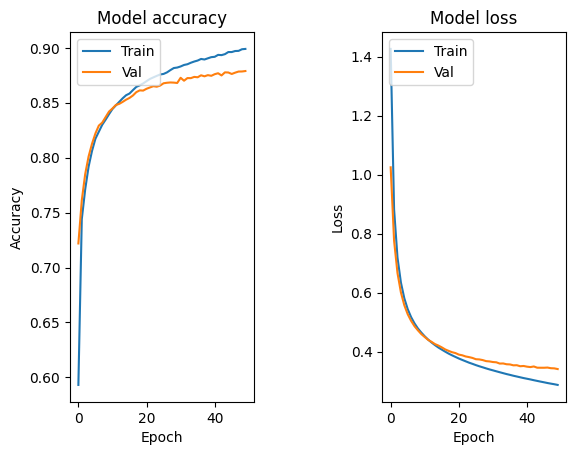

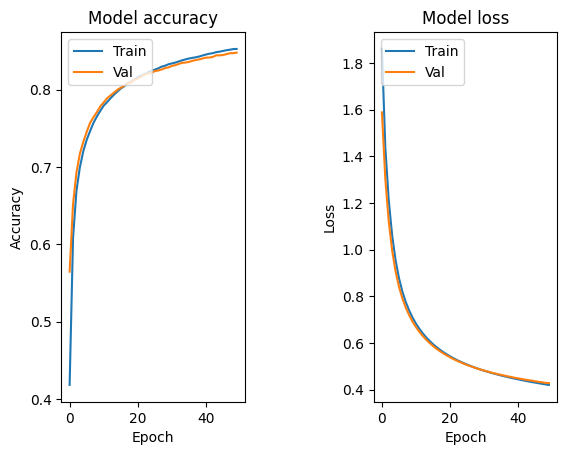

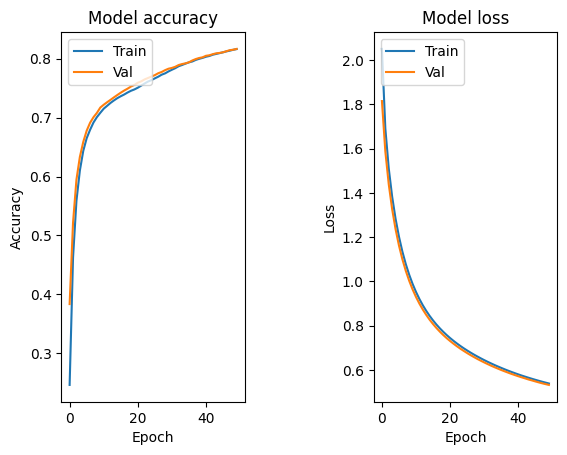

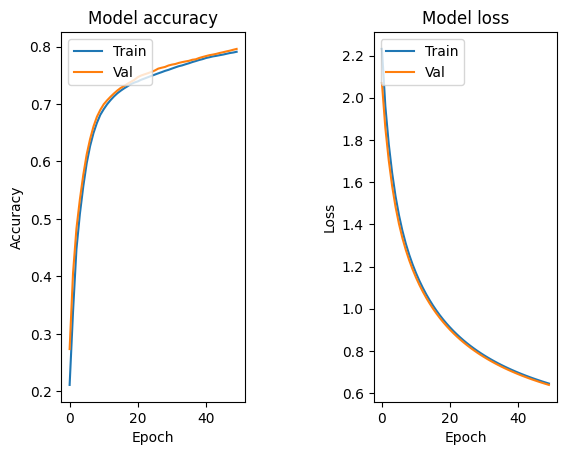

In [ ]:
plot_history(history_5dl_64n_tanh)
plt.show()

plot_history(history_128batchsize)
plt.show()

plot_history(history_256batchsize)
plt.show()

plot_history(history_512batchsize)

#### **5 hidden layers, 128 neurons, Tanh activation function**

In [ ]:
# Activation function
act_func = 'tanh'

#### 32 Batch Size

In [ ]:
train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 32 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9114 - loss: 0.2543
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8737 - loss: 0.3626
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8861 - loss: 0.3175
MODEL 1, 5 layers, 128 neurons, Tanh activation function, 32 batch size

Final Training loss:
0.25204211473464966
Final Validation loss:
0.3256101608276367

Final Test loss:
0.36238521337509155
Final Test accuracy:
0.8705999851226807

Final Training accuracy:
0.9109333157539368
Final Validation accuracy:
0.8841999769210815

Train: 0.911, Test: 0.871


#### 128 Batch Size

In [ ]:
model_5dl_128n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 128

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_128batchsize = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size[1], epochs = epochs, validation_data = (x_val_std, y_val));

train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 128 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_127 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_129 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_130 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_131 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_132 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3126 - loss: 2.0105 - val_accuracy: 0.6423 - val_loss: 1.3074
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6609 - loss: 1.2217 - val_accuracy: 0.7081 - val_loss: 1.0217
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7137 - loss: 0.9865 - val_accuracy: 0.7367 - val_loss: 0.8768
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7354 - loss: 0.8569 - val_accuracy: 0.7529 - val_loss: 0.7887
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7502 - loss: 0.7790 - val_accuracy: 0.7638 - val_loss: 0.7297
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7577 - loss: 0.7277 - val_accuracy: 0.7727 - val_loss: 0.6869
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7698 - loss: 0.6870 - val_accuracy: 0.7830 - val_loss: 0.6539
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7784 - loss: 0.6558 - val_accuracy: 

#### 256 Batch Size

In [ ]:
model_5dl_128n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 128

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_256batchsize = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size[2], epochs = epochs, validation_data = (x_val_std, y_val));

train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 256 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_18 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_133 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_134 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_135 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_136 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_137 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_138 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2311 - loss: 2.1413 - val_accuracy: 0.5442 - val_loss: 1.6197
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5789 - loss: 1.5243 - val_accuracy: 0.6463 - val_loss: 1.3121
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6549 - loss: 1.2653 - val_accuracy: 0.6827 - val_loss: 1.1485
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6878 - loss: 1.1168 - val_accuracy: 0.7045 - val_loss: 1.0419
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7068 - loss: 1.0191 - val_accuracy: 0.7173 - val_loss: 0.9654
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7176 - loss: 0.9478 - val_accuracy: 0.7289 - val_loss: 0.9075
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7270 - loss: 0.8937 - val_accuracy: 0.7359 - val_loss: 0.8618
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7360 - loss: 0.8539 - val_accura

#### 512 Batch Size

In [ ]:
model_5dl_128n_tanh = Sequential();

# Number of neurons for each hidden layer
n_neurons = 128

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_512batchsize = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size[3], epochs = epochs, validation_data = (x_val_std, y_val));

train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 512 batch size")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_19 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_139 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_140 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_141 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_142 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_143 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_144 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.1836 - loss: 2.2600 - val_accuracy: 0.3878 - val_loss: 1.9191
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4435 - loss: 1.8374 - val_accuracy: 0.5623 - val_loss: 1.6377
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5784 - loss: 1.5881 - val_accuracy: 0.6087 - val_loss: 1.4661
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6130 - loss: 1.4341 - val_accuracy: 0.6401 - val_loss: 1.3468
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6459 - loss: 1.3193 - val_accuracy: 0.6632 - val_loss: 1.2559
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6604 - loss: 1.2380 - val_accuracy: 0.6803 - val_loss: 1.1826
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6747 - loss: 1.1727 - val_accuracy: 0.6915 - val_loss: 1.1217
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6845 - loss: 1.1139 - val_accuracy: 0.7016 - v

#### Plot evaluation

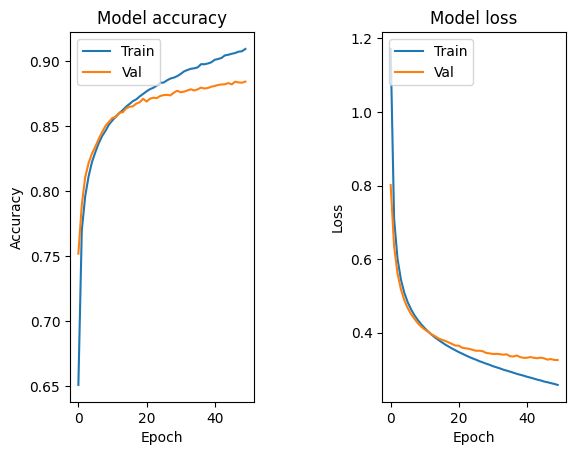

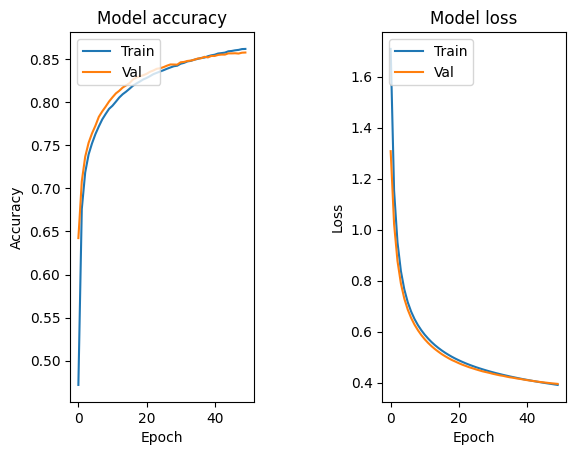

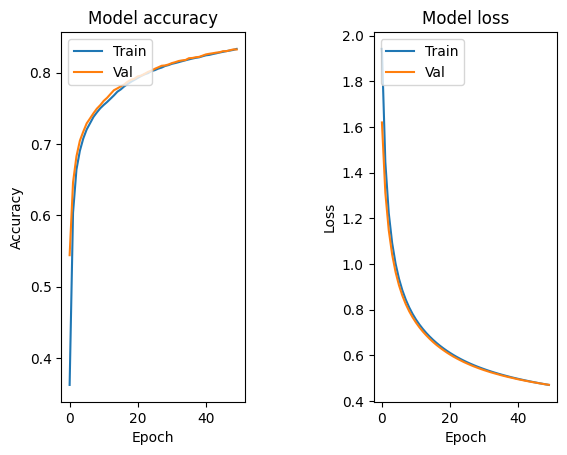

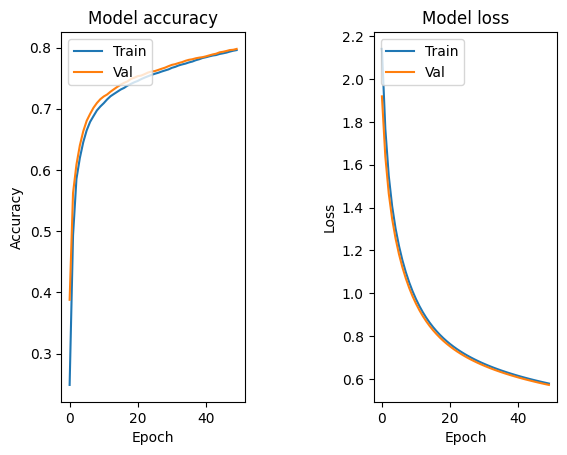

In [ ]:
plot_history(history_5dl_128n_tanh)
plt.show()

plot_history(history_128batchsize)
plt.show()

plot_history(history_256batchsize)
plt.show()

plot_history(history_512batchsize)

### **Build and training MLP model, fifth configuration**
Until now we found that the best models are:

*   5 Dense hidden Layers, 32 neurons, Tanh activation function and 128 as batch size for the training.
*   5 Dense hidden Layers, 64 neurons, ReLU activation function and 128 as batch size for the training.
*  5 Dense hidden Layers, 128 neurons, Tanh activation function and 128 as batch size for the training.

What we want to test now is the best number of epochs for training, 50 100 or 500.




#### **5 Dense Layer, 32 neurons, Tanh activation, 128 batch size**

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 32

# Batch size
batch_size = 128

# Activation function
act_func = 'tanh'

#### 50 epochs

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 32

# Batch size
batch_size = 128

# Activation function
act_func = 'tanh'

# Epochs
epochs = 50

# MODEL
model_5dl_32n_tanh = Sequential()

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_32n_50epochs = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()


train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 256 batch size, 100 epochs")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_32 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_217 (Dense)                    │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_218 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_219 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_220 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_221 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_222 (Dense)                    │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2513 - loss: 2.1610 - val_accuracy: 0.4445 - val_loss: 1.8366
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4732 - loss: 1.7715 - val_accuracy: 0.5430 - val_loss: 1.5909
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5614 - loss: 1.5533 - val_accuracy: 0.6199 - val_loss: 1.4300
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6246 - loss: 1.4081 - val_accuracy: 0.6510 - val_loss: 1.3123
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6499 - loss: 1.2981 - val_accuracy: 0.6685 - val_loss: 1.2205
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6685 - loss: 1.2064 - val_accuracy: 0.6821 - val_loss: 1.1460
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6829 - loss: 1.1350 - val_accuracy: 0.6919 - val_loss: 1.0835
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6909 - loss: 1.0762 - val_accuracy: 0.

#### 100 epochs

In [ ]:
# Epochs
epochs = 100

# MODEL
model_5dl_32n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_32n_100epochs = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()


train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 256 batch size, 100 epochs")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_21 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_151 (Dense)                    │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_152 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_153 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_154 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_155 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_156 (Dense)                    │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2489 - loss: 2.1731 - val_accuracy: 0.4992 - val_loss: 1.8269
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5167 - loss: 1.7583 - val_accuracy: 0.5708 - val_loss: 1.5666
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5768 - loss: 1.5301 - val_accuracy: 0.6190 - val_loss: 1.3993
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6257 - loss: 1.3720 - val_accuracy: 0.6571 - val_loss: 1.2779
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6586 - loss: 1.2608 - val_accuracy: 0.6841 - val_loss: 1.1832
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6856 - loss: 1.1695 - val_accuracy: 0.7100 - val_loss: 1.1060
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7053 - loss: 1.0969 - val_accuracy: 0.7289 - val_loss: 1.0413
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7180 - loss: 1.0414 - val_accu

#### Evaluation plot

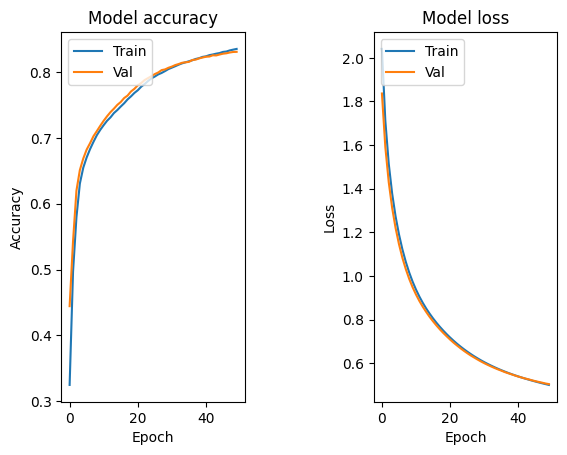

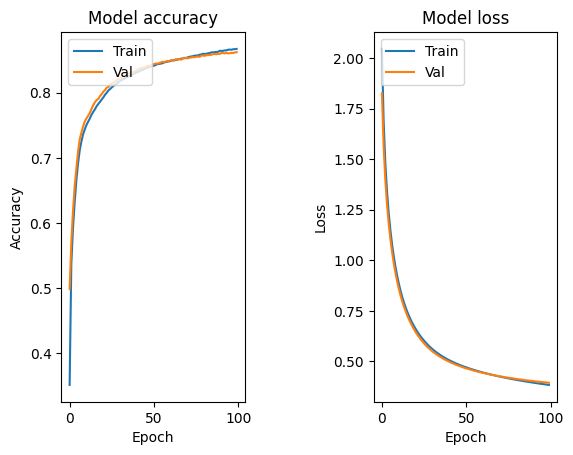

In [ ]:
plot_history(history_32n_50epochs)
plt.show()

plot_history(history_32n_100epochs)
plt.show()

#plot_history(history_32n_500epochs)
#plt.show()

#### **5 Dense Layer, 64 neurons, Tanh activation, 128 batch size**

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 64

# Batch size
batch_size = 128

# Activation function
act_func = 'tanh'

#### 50 epochs

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 64

# Batch size
batch_size = 128

# Activation function
act_func = 'tanh'

# Epochs
epochs = 50

# MODEL
model_5dl_64n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_64n_50epochs = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 256 batch size, 50 epochs")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_33 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_223 (Dense)                    │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_224 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_225 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_226 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_227 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_228 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2366 - loss: 2.1818 - val_accuracy: 0.5569 - val_loss: 1.6456
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5801 - loss: 1.5540 - val_accuracy: 0.6309 - val_loss: 1.3155
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6387 - loss: 1.2666 - val_accuracy: 0.6706 - val_loss: 1.1232
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6755 - loss: 1.0964 - val_accuracy: 0.7069 - val_loss: 1.0012
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7077 - loss: 0.9862 - val_accuracy: 0.7324 - val_loss: 0.9177
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7336 - loss: 0.9069 - val_accuracy: 0.7495 - val_loss: 0.8566
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7531 - loss: 0.8422 - val_accuracy: 0.7591 - val_loss: 0.8091
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7577 - loss: 0.8029 - val_accuracy: 0.

#### 100 epochs

In [ ]:
# Epochs
epochs = 100

# MODEL
model_5dl_64n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_64n_100epochs = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 256 batch size, 100 epochs")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()
print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_23 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_163 (Dense)                    │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_164 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_165 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_166 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_167 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_168 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2432 - loss: 2.1614 - val_accuracy: 0.5108 - val_loss: 1.6877
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5355 - loss: 1.5998 - val_accuracy: 0.6221 - val_loss: 1.3839
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6312 - loss: 1.3377 - val_accuracy: 0.6765 - val_loss: 1.2038
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6798 - loss: 1.1746 - val_accuracy: 0.7063 - val_loss: 1.0766
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7062 - loss: 1.0560 - val_accuracy: 0.7257 - val_loss: 0.9809
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7215 - loss: 0.9676 - val_accuracy: 0.7391 - val_loss: 0.9068
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7369 - loss: 0.8969 - val_accuracy: 0.7487 - val_loss: 0.8484
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7453 - loss: 0.8442 - val_accu

#### Evaluation plot

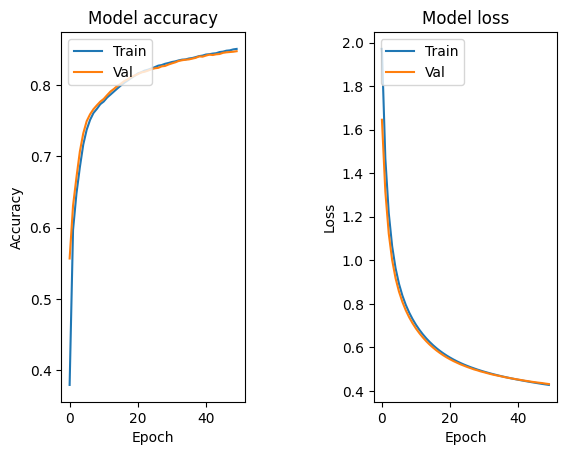

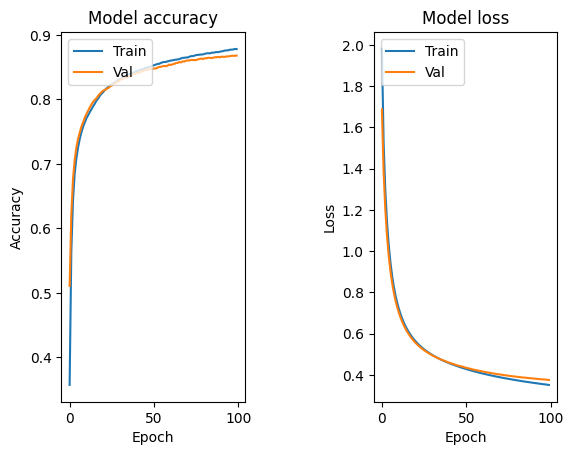

In [ ]:
plot_history(history_64n_50epochs)
plt.show()

plot_history(history_64n_100epochs)
plt.show()

#### **5 Dense Lyer, 128 neurons, Tanh activation, 128 batch size**

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 128

# Batch size
batch_Size = 128

# Activation function
act_func = 'tanh'

#### 50 epochs

In [ ]:
# Epochs
epochs = 50

# MODEL
model_5dl_128n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_128n_50epochs = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 512 batch size, 50 epochs")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_24 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_169 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_170 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_171 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_172 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_173 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_174 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3189 - loss: 1.9685 - val_accuracy: 0.6240 - val_loss: 1.3375
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6465 - loss: 1.2562 - val_accuracy: 0.7035 - val_loss: 1.0591
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7059 - loss: 1.0214 - val_accuracy: 0.7325 - val_loss: 0.9146
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7308 - loss: 0.8966 - val_accuracy: 0.7469 - val_loss: 0.8248
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7497 - loss: 0.8106 - val_accuracy: 0.7564 - val_loss: 0.7635
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7534 - loss: 0.7574 - val_accuracy: 0.7660 - val_loss: 0.7187
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7643 - loss: 0.7147 - val_accuracy: 0.7751 - val_loss: 0.6835
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7766 - loss: 0.6772 - val_accuracy:

#### 100 epochs

In [ ]:
# Epochs
epochs = 100

# MODEL
model_5dl_128n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_128n_100epochs = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 512 batch size, 100 epochs")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_25 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_175 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_176 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_177 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_178 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_179 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_180 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2821 - loss: 2.0650 - val_accuracy: 0.6359 - val_loss: 1.3791
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6506 - loss: 1.2909 - val_accuracy: 0.7010 - val_loss: 1.0706
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7064 - loss: 1.0314 - val_accuracy: 0.7286 - val_loss: 0.9185
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7283 - loss: 0.8983 - val_accuracy: 0.7431 - val_loss: 0.8275
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7464 - loss: 0.8130 - val_accuracy: 0.7549 - val_loss: 0.7667
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7546 - loss: 0.7618 - val_accuracy: 0.7633 - val_loss: 0.7219
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7582 - loss: 0.7255 - val_accuracy: 0.7718 - val_loss: 0.6878
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7711 - loss: 0.6856 - val_accu

#### Evaluation plot

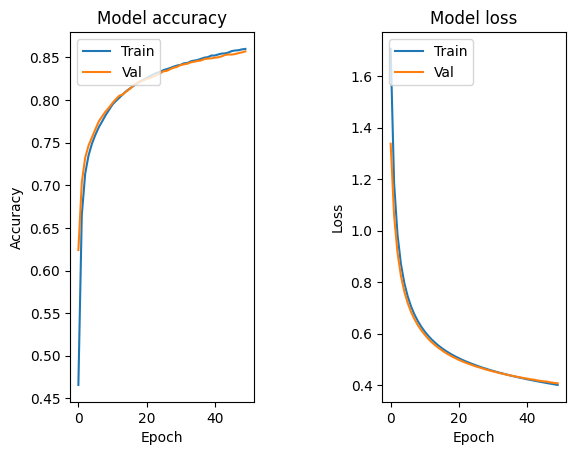

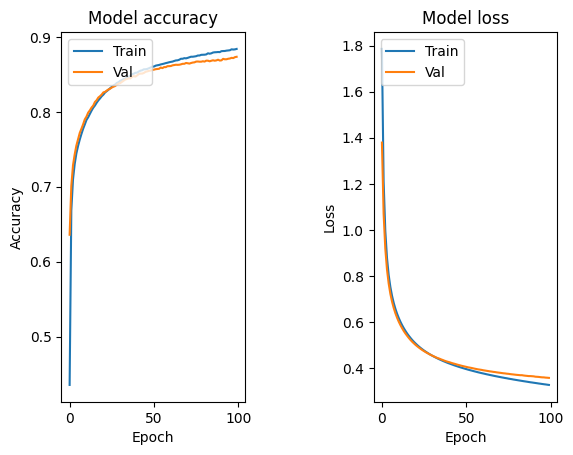

In [ ]:
plot_history(history_128n_50epochs)
plt.show()

plot_history(history_128n_100epochs)
plt.show()

### **Build and Training MLP model, sixth configuration**
We try two different optimizer SGD and ADAM.

In [ ]:
from tensorflow.keras.optimizers import Adam

#### **5 Dense Layers, 32 neurons, Tanh activation, 128 Batch size, 100 epochs**

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 32

# Batch size
batch_size = 128

# Activation function
act_func = 'tanh'

# Epochs
epochs = 100

#### SGD Optimizer


In [ ]:
# MODEL
model_5dl_32n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_32n_SGD = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()


train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 256 batch size, 100 epochs, SGD")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_26 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_181 (Dense)                    │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_182 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_183 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_184 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_185 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_186 (Dense)                    │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2180 - loss: 2.1960 - val_accuracy: 0.4519 - val_loss: 1.8463
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4758 - loss: 1.7881 - val_accuracy: 0.5505 - val_loss: 1.6216
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5613 - loss: 1.5761 - val_accuracy: 0.6135 - val_loss: 1.4570
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6153 - loss: 1.4239 - val_accuracy: 0.6541 - val_loss: 1.3314
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6563 - loss: 1.3029 - val_accuracy: 0.6849 - val_loss: 1.2293
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6808 - loss: 1.2110 - val_accuracy: 0.7094 - val_loss: 1.1443
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7053 - loss: 1.1282 - val_accuracy: 0.7215 - val_loss: 1.0728
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7197 - loss: 1.0632 - val_accu

#### ADAM Optimizer

In [ ]:
# MODEL
model_5dl_32n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_32n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_32n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_32n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_32n_tanh.add(output)

model_5dl_32n_tanh.summary()

# Optimizer
optimizer = Adam(learning_rate = 0.001)

# Compile the model
model_5dl_32n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_32n_ADAM = model_5dl_32n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()


train_loss, train_acc = model_5dl_32n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_32n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_32n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 32 neurons, Tanh activation function, 256 batch size, 100 epochs, ADAM")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_27 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_187 (Dense)                    │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_188 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_189 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_190 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_191 (Dense)                    │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_192 (Dense)                    │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,674 (115.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6845 - loss: 1.0174 - val_accuracy: 0.8384 - val_loss: 0.4720
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8459 - loss: 0.4402 - val_accuracy: 0.8527 - val_loss: 0.4049
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8639 - loss: 0.3860 - val_accuracy: 0.8567 - val_loss: 0.4035
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8713 - loss: 0.3554 - val_accuracy: 0.8628 - val_loss: 0.3808
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8733 - loss: 0.3478 - val_accuracy: 0.8709 - val_loss: 0.3605
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8795 - loss: 0.3320 - val_accuracy: 0.8719 - val_loss: 0.3604
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8893 - loss: 0.3078 - val_accuracy: 0.8749 - val_loss: 0.3565
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8893 - loss: 0.3020 - val_accu

#### Plot evaluation

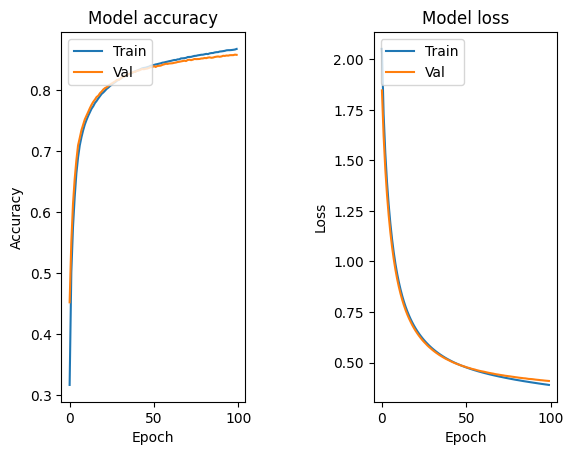

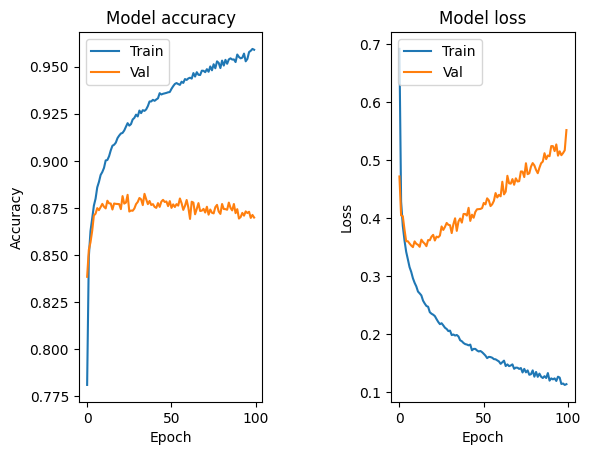

In [ ]:
plot_history(history_32n_SGD)
plt.show()

plot_history(history_32n_ADAM)
plt.show()

#### **5 Dense Layer, 64 neurons, ReLU activation, 128 Batch size, 100 epochs**

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 64

# Batch size
batch_size = 128

# Activation function
act_func = 'tanh'

# Epochs
epochs = 100

#### SGD Optimizer

In [ ]:
# MODEL
model_5dl_64n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_64n_SGD = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 256 batch size, 100 epochs, SGD")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_28 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_193 (Dense)                    │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_194 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_195 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_196 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_197 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_198 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2349 - loss: 2.1389 - val_accuracy: 0.5091 - val_loss: 1.7217
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5548 - loss: 1.6344 - val_accuracy: 0.6361 - val_loss: 1.3933
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6479 - loss: 1.3408 - val_accuracy: 0.6843 - val_loss: 1.1818
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6906 - loss: 1.1469 - val_accuracy: 0.7140 - val_loss: 1.0401
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7135 - loss: 1.0175 - val_accuracy: 0.7310 - val_loss: 0.9413
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7280 - loss: 0.9278 - val_accuracy: 0.7419 - val_loss: 0.8702
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7382 - loss: 0.8649 - val_accuracy: 0.7501 - val_loss: 0.8171
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7449 - loss: 0.8146 - val_accu

#### ADAM Optimizer

In [ ]:
# MODEL
model_5dl_64n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_64n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_64n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_64n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_64n_tanh.add(output)

model_5dl_64n_tanh.summary()

# Optimizer
optimizer = Adam(learning_rate = 0.001)

# Compile the model
model_5dl_64n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_64n_ADAM = model_5dl_64n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_64n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_64n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_64n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 64 neurons, Tanh activation function, 256 batch size, 100 epochs, ADAM")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_29 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_199 (Dense)                    │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_200 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_201 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_202 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_203 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_204 (Dense)                    │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7444 - loss: 0.7695 - val_accuracy: 0.8527 - val_loss: 0.4110
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8576 - loss: 0.3905 - val_accuracy: 0.8593 - val_loss: 0.3854
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8727 - loss: 0.3504 - val_accuracy: 0.8725 - val_loss: 0.3521
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8802 - loss: 0.3246 - val_accuracy: 0.8735 - val_loss: 0.3551
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8856 - loss: 0.3140 - val_accuracy: 0.8831 - val_loss: 0.3269
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8931 - loss: 0.2902 - val_accuracy: 0.8763 - val_loss: 0.3450
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8978 - loss: 0.2760 - val_accuracy: 0.8755 - val_loss: 0.3473
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9004 - loss: 0.2709 - val_accu

#### Plot evaluation

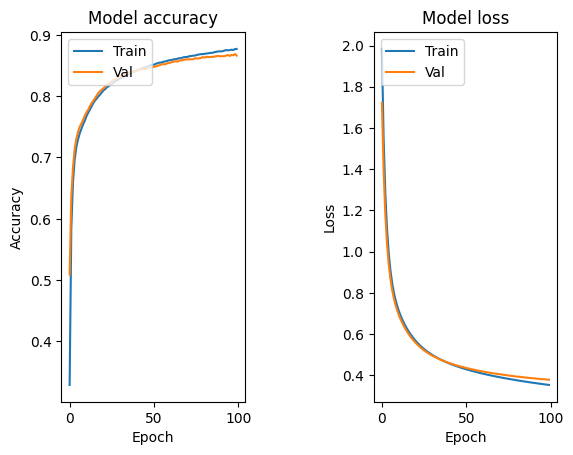

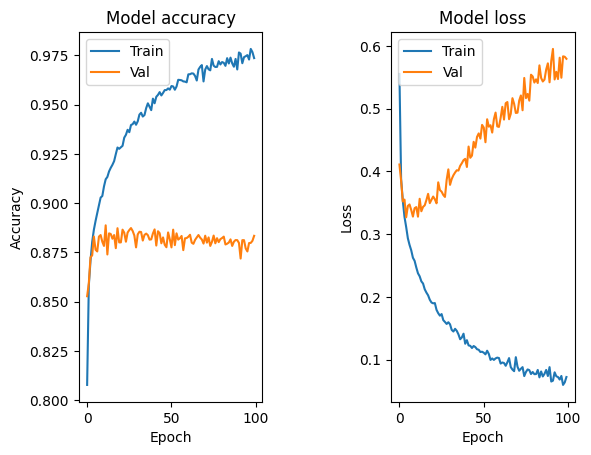

In [ ]:
plot_history(history_64n_SGD)
plt.show()

plot_history(history_64n_ADAM)
plt.show()

#### **5 Dense Layers, 128 neurons, Tanh activation, 128 batch size, 100 epochs**

In [ ]:
# Number of Dense Layers
n_hidden_layers = 5;

# Number of neurons for each hidden layer
n_neurons = 128

# Batch size
batch_Size = 128

# Activation function
act_func = 'tanh'

# Epochs
epochs = 100

#### SGD Activation

In [ ]:
# MODEL
model_5dl_128n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = SGD(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_128n_SGD = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 512 batch size, 100 epochs, SGD")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_30 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_205 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_206 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_207 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_208 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_209 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_210 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3430 - loss: 1.9633 - val_accuracy: 0.6521 - val_loss: 1.3005
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6626 - loss: 1.2231 - val_accuracy: 0.7135 - val_loss: 1.0216
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7166 - loss: 0.9883 - val_accuracy: 0.7395 - val_loss: 0.8809
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7412 - loss: 0.8618 - val_accuracy: 0.7537 - val_loss: 0.7962
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7525 - loss: 0.7877 - val_accuracy: 0.7652 - val_loss: 0.7396
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7645 - loss: 0.7335 - val_accuracy: 0.7733 - val_loss: 0.6983
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7735 - loss: 0.6916 - val_accuracy: 0.7782 - val_loss: 0.6666
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7804 - loss: 0.6664 - val_ac

#### ADAM Activation

In [ ]:
# MODEL
model_5dl_128n_tanh = Sequential();

# Initialization of the input layer
input = InputLayer( shape=(28,28,1) )
model_5dl_128n_tanh.add(input)

# Flatten layer, this will vectorize each image
vectorize = Flatten()
model_5dl_128n_tanh.add(vectorize)

# Dense layers
for i in range(n_hidden_layers):
 model_5dl_128n_tanh.add(Dense(n_neurons,activation = act_func));

# Output layer
output = Dense(len_class,activation = 'softmax')
model_5dl_128n_tanh.add(output)

model_5dl_128n_tanh.summary()

# Optimizer
optimizer = Adam(learning_rate = 0.001)

# Compile the model
model_5dl_128n_tanh.compile(optimizer = optimizer, loss = ['categorical_crossentropy'] , metrics = ['accuracy'] )

history_128n_ADAM = model_5dl_128n_tanh.fit(x_train_std, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val_std, y_val));
print()

train_loss, train_acc = model_5dl_128n_tanh.evaluate(x_train_std, y_train, verbose = 1)
test_loss, test_acc = model_5dl_128n_tanh.evaluate(x_test_std, y_test, verbose = 1)
val_loss, val_acc = model_5dl_128n_tanh.evaluate(x_val_std,y_val, verbose = 1)
print("MODEL 1, 5 layers, 128 neurons, Tanh activation function, 512 batch size, 100 epochs, ADAM")
print()

print('Final Training loss:')
print(train_loss);
print("Final Validation loss:")
print(val_loss);

print()
print('Final Test loss:')
print(test_loss)
print('Final Test accuracy:')
print(test_acc)
print()

print('Final Training accuracy:')
print(train_acc);
print("Final Validation accuracy:")
print(val_acc);

print()

print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_31 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_211 (Dense)                    │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_212 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_213 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_214 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_215 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_216 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7748 - loss: 0.6366 - val_accuracy: 0.8536 - val_loss: 0.4049
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8569 - loss: 0.3911 - val_accuracy: 0.8609 - val_loss: 0.3757
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8742 - loss: 0.3386 - val_accuracy: 0.8669 - val_loss: 0.3657
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8843 - loss: 0.3096 - val_accuracy: 0.8797 - val_loss: 0.3279
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8878 - loss: 0.2977 - val_accuracy: 0.8739 - val_loss: 0.3490
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8979 - loss: 0.2796 - val_accuracy: 0.8826 - val_loss: 0.3274
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9005 - loss: 0.2674 - val_accuracy: 0.8811 - val_loss: 0.3319
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9069 - loss: 0.2512 - val_ac

#### Plot evaluation

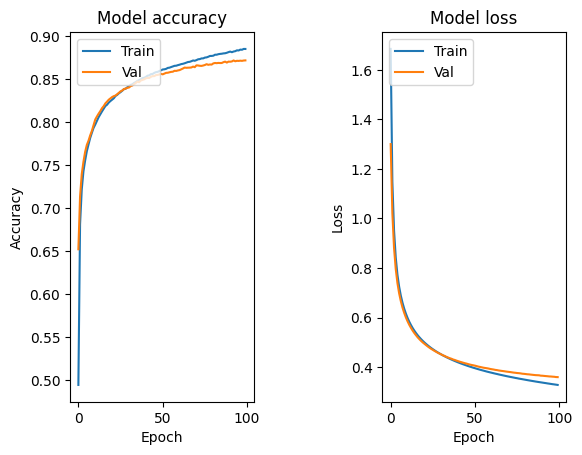

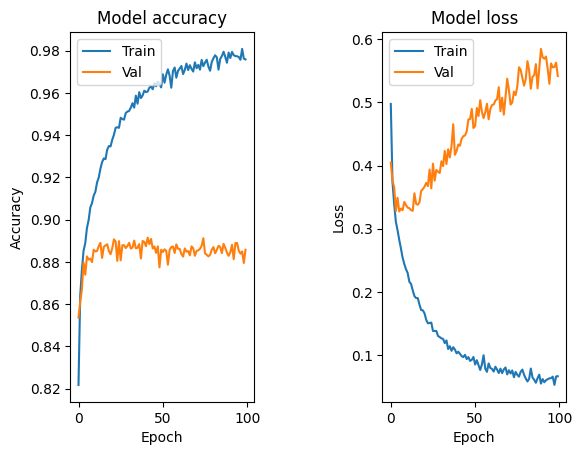

In [ ]:
plot_history(history_128n_SGD)
plt.show()

plot_history(history_128n_ADAM)
plt.show()